# M11.15B — Latent domain geometry
Interpretation only: frozen **E10 / G0-final** and **E11 / G1-final**, and **R**, the nine successful M11.14 events. No retraining, dataset regeneration, Mondrian fitting or sweeps. Run sections explicitly; construction does not execute inference or geometry.

Raw distances from E10 and E11 are never compared: each encoder defines its own coordinate system. Compare domain-normalized ratios and empirical OOD percentiles descriptively. Domain differences include multiple generation choices and cannot identify an individual causal mechanism.

## 1. Contract and provenance
Diagonals are reused exactly, preserving their test order. E10(G1) receives already normalized G1 inputs directly; E11(G0) receives G0 inputs z-scored **once**, epsilon 1e-6. All inference inputs are float32. Only batches of the exact 30k test indices are read, never complete signal arrays.

Cached results must match shapes, finite values, ordered indices and provenance. Incompatible caches stop execution rather than silently overwrite. The GPU script saves cross terms and real-event pairs immediately; incomplete caches require --force. Dataset fingerprints use path/size/mtime (not a full dataset content hash); checkpoint and small contract files use SHA256.

In [1]:
from pathlib import Path
import sys, json, hashlib, os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.decomposition import PCA

root = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "src/paths.py").is_file()), None)
if root is None:
    raise RuntimeError("Open from cbc_pe")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.paths import resolve_project_root, resolve_data_root
PROJECT_ROOT = resolve_project_root()
DATA_ROOT = resolve_data_root(config_data_root="/data/vserrano/cbc_pe_data")
if DATA_ROOT.resolve() != Path("/data/vserrano/cbc_pe_data").resolve():
    raise ValueError("DATA_ROOT differs from frozen paths")
G0_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
G1_ID = "M11_final_G1_500k"
DATASETS = {"G0": DATA_ROOT / "processed" / G0_ID / f"{G0_ID}.h5",
            "G1": DATA_ROOT / "processed" / G1_ID / "m11_final_G1_500k_trainio.h5"}
COMPACT_G0 = DATA_ROOT / "processed/M11_15B_temp/G0_test30k_model_input_source.h5"
G0_SOURCE = "compact_test30k" if COMPACT_G0.is_file() else "full_dataset"
if G0_SOURCE == "compact_test30k":
    DATASETS["G0"] = COMPACT_G0
SPLITS = {d: DATA_ROOT / "processed" / name /
          f"{name}_splits_train400000_val40000_cal30000_test30000_seed123.npz"
          for d,name in [("G0",G0_ID),("G1",G1_ID)]}
CHECKPOINTS = {
 "E10": DATA_ROOT / "models/checkpoints" / G0_ID / f"{G0_ID}_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt",
 "E11": DATA_ROOT / "models/checkpoints" / G1_ID / "M11_final_G1_500k_SimpleCNN_ResidualDilated_M11_final_G1_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt"}
DIAGONALS = {
 "G0": DATA_ROOT / "results" / G0_ID / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
 "G1": DATA_ROOT / "results" / G1_ID / "m11_final_G1_500k_cal_test_predictions_embeddings.npz"}
REAL_DIR = DATA_ROOT / "results/M11_final_G1_500k/real_events/multi_event"
STATUS_PATH = REAL_DIR / "event_status.csv"
COMPARISON_PATH = REAL_DIR / "per_event_comparison.csv"
REAL_PROVENANCE_PATH = REAL_DIR / "provenance.json"
GEN_PATH = PROJECT_ROOT / "configs/generation/generate_500k_bbh_4s.json"
ANCHOR_PATH = DATA_ROOT / "results/M11_final_G1_500k/real_events/GW170814/predictions_embeddings.npz"
M15A_PATH = DATA_ROOT / "results/M11_final_G1_500k/M11_15_result_interpretation/real_event_diagnostics.csv"
RESULT_ROOT = DATA_ROOT / "results/M11_final_G1_500k/M11_15B_latent_domain_geometry"
FIGURE_DIR = RESULT_ROOT / "figures"
CROSS_CACHE = RESULT_ROOT / "latent_cross_embeddings.npz"
REAL_CACHE = RESULT_ROOT / "real_event_embeddings.npz"
LABELS = ["chirp_mass", "total_mass", "chi_eff"]
KS = (20, 50, 100)
SEED = 123

def require(condition, message):
    if not condition:
        raise ValueError(message)

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024*1024), b""):
            digest.update(block)
    return digest.hexdigest()

def fingerprint(path, content=False):
    path = Path(path)
    stat = path.stat()
    result = dict(path=str(path.resolve()), size=stat.st_size, mtime_ns=stat.st_mtime_ns)
    if content:
        result["sha256"] = sha256(path)
    return result

def array_hash(a):
    return hashlib.sha256(np.ascontiguousarray(a).tobytes()).hexdigest()

def valid_embedding(a, n):
    return a.shape == (n,64) and np.isfinite(a).all()

def save_npz(path, arrays):
    temporary = path.with_name(path.name + ".tmp")
    with temporary.open("wb") as stream:
        np.savez_compressed(stream, **arrays)
    os.replace(temporary, path)

required_paths = [*DATASETS.values(), *SPLITS.values(), *CHECKPOINTS.values(),
                  *DIAGONALS.values(), STATUS_PATH, COMPARISON_PATH, REAL_PROVENANCE_PATH, GEN_PATH]
for cache_path in (CROSS_CACHE, REAL_CACHE):
    require(cache_path.is_file(), f"Missing {cache_path}. Run on the GPU VM in cbc_torch: python scripts/generate_m11_15b_latent_embeddings.py --all")
for path in required_paths:
    require(path.is_file(), f"Missing frozen input: {path}")
display(pd.DataFrame({"input": [str(p) for p in required_paths]}))
idx, labels_std, diagonal = {}, {}, {}
for domain,encoder in [("G0","E10"),("G1","E11")]:
    with np.load(DIAGONALS[domain], allow_pickle=False) as z:
        diagonal[f"emb_{encoder}_{domain}"] = z["emb_test"].copy()
        idx[domain] = z["idx_test"].copy()
        labels_std[domain] = z["y_test"].copy()
        require(z["label_names"].tolist() == LABELS, "Label order changed")
    require(valid_embedding(diagonal[f"emb_{encoder}_{domain}"],30000), "Diagonal shape/finite")
    require(labels_std[domain].shape == (30000,3) and np.isfinite(labels_std[domain]).all(), "Test labels")
    require(idx[domain].shape == (30000,) and np.issubdtype(idx[domain].dtype,np.integer)
            and len(np.unique(idx[domain])) == 30000 and (idx[domain]>=0).all(), "Test indices")
    with np.load(SPLITS[domain], allow_pickle=False) as z:
        keys = [k for k in ("idx_test","test_idx","test_indices","test") if k in z.files]
        require(len(keys) == 1, f"Ambiguous test split keys: {z.files}")
        require(np.array_equal(np.sort(z[keys[0]]),np.sort(idx[domain])), "Test membership changed")
    with h5py.File(DATASETS[domain],"r") as h:
        if domain == "G0" and G0_SOURCE == "compact_test30k":
            require("X" in h and "original_idx_test" in h, "Compact G0 missing X/original_idx_test")
            require(h["X"].shape == (30000,3,16384), "Compact G0 X shape")
            require(h["X"].dtype == np.dtype("float32"), "Compact G0 X must be float32")
            require(h["original_idx_test"].shape == (30000,)
                    and np.issubdtype(h["original_idx_test"].dtype,np.integer)
                    and np.array_equal(h["original_idx_test"][:],idx["G0"]),
                    "Compact G0 original_idx_test differs from frozen artifact order")
        else:
            require(h["X"].shape[1:] == (3,16384) and idx[domain].max()<len(h["X"]), "Dataset dimensions")
status = pd.read_csv(STATUS_PATH)
require(not status.event.duplicated().any(), "Duplicate events")
cohort = status.loc[status.processing_status.eq("success")].copy().reset_index(drop=True)
event_names = cohort.event.astype(str).tolist()
require(len(event_names) == 9, "Frozen cohort must contain exactly nine successful events")
require("GW170814" not in event_names, "M11.14 cohort changed: inspect before proceeding")
real_provenance = json.loads(REAL_PROVENANCE_PATH.read_text())
nominal_policy = dict(psd_window=[-1024.0,-640.0], center_offset=0.0,
                      psd_segment_duration=8.0, fallback_windows=[], zscore_eps=1e-6)
require(real_provenance["nominal_policy"] == nominal_policy, "M11.14 nominal policy changed")
contract = dict(version=1, labels=LABELS, latent_dimension=64,
    g0_source=G0_SOURCE,
    datasets={d:fingerprint(p) for d,p in DATASETS.items()},
    splits={d:fingerprint(p,True) for d,p in SPLITS.items()},
    diagonals={d:fingerprint(p) for d,p in DIAGONALS.items()},
    checkpoints={e:fingerprint(p,True) for e,p in CHECKPOINTS.items()},
    test_index_sha256={d:array_hash(v) for d,v in idx.items()},
    diagonal_sha256={k:array_hash(v) for k,v in diagonal.items()},
    normalization={"G0":"zscore once eps=1e-6 before E11", "G1":"already normalized; feed E10 directly"})
contract_json = json.dumps(contract,sort_keys=True)
RESULT_ROOT.mkdir(parents=True,exist_ok=True)
FIGURE_DIR.mkdir(parents=True,exist_ok=True)
display(cohort[["event","gps_time","network_snr_lvk"]])


,input
0,/data/vserrano/cbc_pe_data/processed/M11_15B_t...
1,/data/vserrano/cbc_pe_data/processed/M11_final...
2,/data/vserrano/cbc_pe_data/processed/bbh_proce...
3,/data/vserrano/cbc_pe_data/processed/M11_final...
4,/data/vserrano/cbc_pe_data/models/checkpoints/...
5,/data/vserrano/cbc_pe_data/models/checkpoints/...
6,/data/vserrano/cbc_pe_data/results/bbh_process...
7,/data/vserrano/cbc_pe_data/results/M11_final_G...
8,/data/vserrano/cbc_pe_data/results/M11_final_G...
9,/data/vserrano/cbc_pe_data/results/M11_final_G...


,event,gps_time,network_snr_lvk
0,GW200202_154313,1.264693e+09,10.8
1,GW200316_215756,1.268431e+09,10.3
2,GW191215_223052,1.260484e+09,11.2
3,GW200129_065458,1.264316e+09,26.8
4,GW200311_115853,1.267963e+09,17.8
5,GW200208_130117,1.265202e+09,10.8
6,GW200224_222234,1.266618e+09,20.0
7,GW200219_094415,1.266141e+09,10.7
8,GW191230_180458,1.261764e+09,10.4


## 2. Load synthetic cross embeddings — cache only
Generate missing caches on the GPU VM in `cbc_torch`, from the repository root:

```bash
python scripts/generate_m11_15b_latent_embeddings.py --all
```

This notebook validates and loads caches only; it never starts inference.
The script generates only E10(G1) and E11(G0), reusing both existing diagonals.
Missing caches stop with instructions; invalid or incomplete caches require an
explicit script run with `--force` to regenerate the selected artifacts.


In [2]:
def load_cache(path, validator):
    try:
        with np.load(path, allow_pickle=False) as archive:
            cached = {key: archive[key].copy() for key in archive.files}
        validator(cached)
        return cached
    except Exception as error:
        raise ValueError(f"Invalid or incompatible cache {path}: {error}. "
                         "Inspect provenance before regenerating.") from error

def validate_cross(cached):
    required = {"emb_E10_G0", "emb_E10_G1", "emb_E11_G0", "emb_E11_G1",
                "idx_G0_test", "idx_G1_test", "label_names", "provenance_json"}
    require(required <= cached.keys(), f"Missing keys: {required - cached.keys()}")
    require(cached["provenance_json"].item() == contract_json, "Cross provenance mismatch")
    require(cached["label_names"].tolist() == LABELS, "Cached label order")
    for domain in ("G0", "G1"):
        require(np.array_equal(cached[f"idx_{domain}_test"], idx[domain]), "Cached test order")
        for encoder in ("E10", "E11"):
            require(valid_embedding(cached[f"emb_{encoder}_{domain}"], 30000), "Cached shape/finite")
    for key, value in diagonal.items():
        require(np.array_equal(cached[key], value), "Existing diagonal changed")


require(CROSS_CACHE.is_file(), "Missing latent_cross_embeddings.npz. Run on the GPU VM in cbc_torch: python scripts/generate_m11_15b_latent_embeddings.py --all")
cross = load_cache(CROSS_CACHE, validate_cross)


## 3. Frozen nominal real-event inputs
Use exactly M11.14's nine successes and its nominal preparation: H1/L1/V1, 4096 Hz, 4 s; 1664 context samples per side; frozen generation processor (whitening 0.5 s Hann, filters 30–512 Hz, FIR 256 beta 5, crop); PSD window (−1024, −640) s with 8 s segments; center GPS+0; z-score once after crop, epsilon 1e-6. No fallback or sweep. Same resulting float32 tensor is supplied to E10 and E11.

**GW170814 is outside the frozen M11.14 cohort**, as documented by M11.14. Its existing embedding artifact is therefore neither recomputed nor included in R. No extra anchor event is added.

The GPU script reuses the M11.14 preparation function. Any failed nominal input stops execution without changing the cohort. Completed event pairs are persisted immediately. This notebook only loads the complete validated cache.

In [ ]:
# Real input preparation and CUDA inference now live in scripts/generate_m11_15b_latent_embeddings.py.


In [3]:
model_contract = dict(version=1, labels=LABELS, latent_dimension=64,
    checkpoints={encoder:fingerprint(path,True) for encoder,path in CHECKPOINTS.items()})
real_contract = dict(model_contract=model_contract,
    cohort=fingerprint(STATUS_PATH,True), nominal_provenance=fingerprint(REAL_PROVENANCE_PATH,True),
    generation_config=fingerprint(GEN_PATH,True), events=event_names, policy=nominal_policy)
real_contract_json = json.dumps(real_contract,sort_keys=True)

import json
import numpy as np

with np.load(REAL_CACHE, allow_pickle=False) as z:
    cached_real_raw = z["provenance_json"].item()

cached_real_contract = json.loads(cached_real_raw)

print("=== REAL CACHE PROVENANCE ===")
print(json.dumps(cached_real_contract, indent=2, sort_keys=True))

print("\n=== NOTEBOOK REAL CONTRACT ===")
print(json.dumps(real_contract, indent=2, sort_keys=True))

=== REAL CACHE PROVENANCE ===
{
  "cohort": {
    "mtime_ns": 1791277426452913359,
    "path": "/data/vserrano/cbc_pe_data/results/M11_final_G1_500k/real_events/multi_event/event_status.csv",
    "sha256": "2d07a37ffbeb635832b1861686fbd8aef7365fe2cf35d37855efc69d8e758c8a",
    "size": 6294
  },
  "events": [
    "GW200202_154313",
    "GW200316_215756",
    "GW191215_223052",
    "GW200129_065458",
    "GW200311_115853",
    "GW200208_130117",
    "GW200224_222234",
    "GW200219_094415",
    "GW191230_180458"
  ],
  "generation_config": {
    "mtime_ns": 1783707746000000001,
    "path": "/data/vserrano/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json",
    "sha256": "e7625cb8a4490b2302f31ad4bffa36eff39a7af0fda1b9e52999d232588107ea",
    "size": 1284
  },
  "model_contract": {
    "checkpoints": {
      "E10": {
        "mtime_ns": 1785923490285980094,
        "path": "/data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500

In [4]:
def diff_dict(a, b, prefix=""):
    keys = sorted(set(a) | set(b))

    for k in keys:
        path = f"{prefix}.{k}" if prefix else k

        if k not in a:
            print("ONLY NOTEBOOK:", path, "=", b[k])
            continue

        if k not in b:
            print("ONLY CACHE:", path, "=", a[k])
            continue

        va, vb = a[k], b[k]

        if isinstance(va, dict) and isinstance(vb, dict):
            diff_dict(va, vb, path)
        elif va != vb:
            print("DIFF:", path)
            print("  cache   :", va)
            print("  notebook:", vb)

diff_dict(cached_real_contract, real_contract)

DIFF: generation_config.path
  cache   : /data/vserrano/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json
  notebook: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json


In [5]:
def canonical_real_contract(value):
    # Only the generation-config location differs between machines.
    canonical = dict(value)
    canonical["generation_config"] = dict(value["generation_config"])
    canonical["generation_config"].pop("path", None)
    return canonical

def validate_real(cached):
    required = {"event_names", "emb_E10_real", "emb_E11_real", "provenance_json", "event_metadata_json"}
    require(required <= cached.keys(), f"Missing keys: {required - cached.keys()}")
    require(canonical_real_contract(json.loads(cached["provenance_json"].item()))
            == canonical_real_contract(real_contract),
            "Real provenance mismatch; inspect provenance before regenerating")
    require(cached["event_names"].tolist() == event_names, "Incomplete or changed real cohort/order")
    for encoder in ("E10", "E11"):
        require(valid_embedding(cached[f"emb_{encoder}_real"], len(event_names)), "Real shape/finite")
    records = json.loads(cached["event_metadata_json"].item())
    require(len(records) == len(event_names), "Real metadata length")
    require([record["event"] for record in records] == event_names, "Real metadata event order")

require(REAL_CACHE.is_file(), "Missing real_event_embeddings.npz. Run on the GPU VM in cbc_torch: python scripts/generate_m11_15b_latent_embeddings.py --all")
real_cache = load_cache(REAL_CACHE, validate_real)
metadata = json.loads(real_cache["event_metadata_json"].item())


## 4. One balanced synthetic metric per encoder
One StandardScaler is fit to all 60k synthetic embeddings per encoder, then applied to both domains and R. Domains are not scaled separately and encoder axes are not aligned. This transductive scaling is the specified geometry definition (no real events used); classifier holdout below uses this already-defined representation.

In [6]:
scaled, metric_scalers = {}, {}
for encoder in ("E10","E11"):
    combined = np.concatenate([cross[f"emb_{encoder}_G0"],cross[f"emb_{encoder}_G1"]])
    scaler = StandardScaler().fit(combined)
    metric_scalers[encoder] = scaler
    scaled[encoder] = {d:scaler.transform(cross[f"emb_{encoder}_{d}"]) for d in ("G0","G1")}
    scaled[encoder]["real"] = scaler.transform(real_cache[f"emb_{encoder}_real"])


## 5–8. Exact 64D kNN, normalized distances, OOD and synthetic geometry
Primary k=50, robustness k=20/100. Exact brute-force neighbor queries run in blocks of 128; no full 30k×30k matrix is constructed or persisted. This CPU step can be substantial. For within-domain references, request 101 neighbors and remove the query's **own index**, not an arbitrary zero-distance duplicate. If ties omit self, keep the first 100 nonself neighbors.

Here d_k is distance to the kth neighbor. Normalize by median within-domain d_k. Empirical percentile = 100 × fraction of reference distances ≤ query distance. R_k = normalized G1 distance / normalized G0 distance: <1 favors G1, >1 favors G0. Percentiles describe domain-relative OOD, not probabilities or calibrated hypothesis tests. Synthetic cross/internal geometry is examined before real-event conclusions.

,encoder,k,n_G0,n_G1,median_internal_G0,median_internal_G1,median_G0_to_G1,median_G1_to_G0
0,E10,20,30000,30000,1.175484,1.456001,1.435448,1.678166
1,E10,50,30000,30000,1.475078,1.775439,1.767598,1.996081
2,E10,100,30000,30000,1.772216,2.081327,2.085165,2.305502
3,E11,20,30000,30000,1.238372,1.084750,1.306538,1.156850
4,E11,50,30000,30000,1.565984,1.381800,1.638821,1.466965
5,E11,100,30000,30000,1.895360,1.678671,1.972405,1.780033


E10 primary k=50; robustness retained in combined table


,event,encoder,k,raw_distance_G0,normalized_distance_G0,ood_percentile_G0,raw_distance_G1,normalized_distance_G1,ood_percentile_G1,ratio_G1_over_G0
9,GW200202_154313,E10,50,2.326453,1.577173,89.686667,2.598226,1.463428,86.776667,0.927880
10,GW200316_215756,E10,50,3.527589,2.391460,98.983333,2.990819,1.684552,93.060000,0.704403
11,GW191215_223052,E10,50,4.672473,3.167612,99.890000,4.242579,2.389595,99.143333,0.754384
12,GW200129_065458,E10,50,1.213540,0.822696,27.103333,1.501085,0.845473,29.823333,1.027685
13,GW200311_115853,E10,50,1.579792,1.070989,57.313333,1.638963,0.923132,40.510000,0.861943
14,GW200208_130117,E10,50,1.988564,1.348108,79.580000,2.110994,1.188999,69.503333,0.881976
15,GW200224_222234,E10,50,1.310162,0.888199,36.456667,1.398097,0.787465,22.366667,0.886587
16,GW200219_094415,E10,50,1.496871,1.014775,51.540000,1.556560,0.876719,33.993333,0.863954
17,GW191230_180458,E10,50,2.728384,1.849655,95.150000,2.196726,1.237286,73.470000,0.668928


E11 primary k=50; robustness retained in combined table


,event,encoder,k,raw_distance_G0,normalized_distance_G0,ood_percentile_G0,raw_distance_G1,normalized_distance_G1,ood_percentile_G1,ratio_G1_over_G0
36,GW200202_154313,E11,50,3.080273,1.966989,96.536667,4.222005,3.055440,99.520000,1.553358
37,GW200316_215756,E11,50,2.961383,1.891069,95.570000,3.951443,2.859635,99.306667,1.512179
38,GW191215_223052,E11,50,3.376822,2.156358,98.143333,2.651475,1.918856,94.740000,0.889860
39,GW200129_065458,E11,50,1.278903,0.816677,29.563333,1.106293,0.800618,32.063333,0.980336
40,GW200311_115853,E11,50,1.412349,0.901892,39.483333,1.054173,0.762899,27.890000,0.845887
41,GW200208_130117,E11,50,1.239097,0.791258,26.456667,1.155115,0.835950,35.590000,1.056482
42,GW200224_222234,E11,50,1.123086,0.717176,17.883333,0.888407,0.642935,12.633333,0.896481
43,GW200219_094415,E11,50,1.306029,0.833999,31.673333,0.966749,0.699631,20.120000,0.838887
44,GW191230_180458,E11,50,0.809159,0.516710,0.260000,0.653402,0.472863,0.136667,0.915142


,event,encoder,k,raw_distance_G0,normalized_distance_G0,ood_percentile_G0,raw_distance_G1,normalized_distance_G1,ood_percentile_G1,ratio_G1_over_G0
0,GW200202_154313,E10,20,1.753384,1.491626,87.230000,2.032388,1.395870,82.933333,0.935804
1,GW200316_215756,E10,20,2.619266,2.228244,98.450000,2.495295,1.713801,93.066667,0.769126
2,GW191215_223052,E10,20,4.279444,3.640579,99.956667,3.829368,2.630059,99.500000,0.722429
3,GW200129_065458,E10,20,0.998594,0.849517,30.856667,1.112889,0.764346,20.343333,0.899742
4,GW200311_115853,E10,20,1.268409,1.079052,58.280000,1.402670,0.963372,45.623333,0.892795
5,GW200208_130117,E10,20,1.699695,1.445953,85.270000,1.777992,1.221147,71.660000,0.844528
6,GW200224_222234,E10,20,1.053480,0.896210,37.443333,1.143872,0.785626,23.033333,0.876609
7,GW200219_094415,E10,20,1.291095,1.098352,60.130000,1.215578,0.834874,29.320000,0.760116
8,GW191230_180458,E10,20,2.604923,2.216042,98.420000,1.913475,1.314199,78.326667,0.593039
9,GW200202_154313,E10,50,2.326453,1.577173,89.686667,2.598226,1.463428,86.776667,0.927880


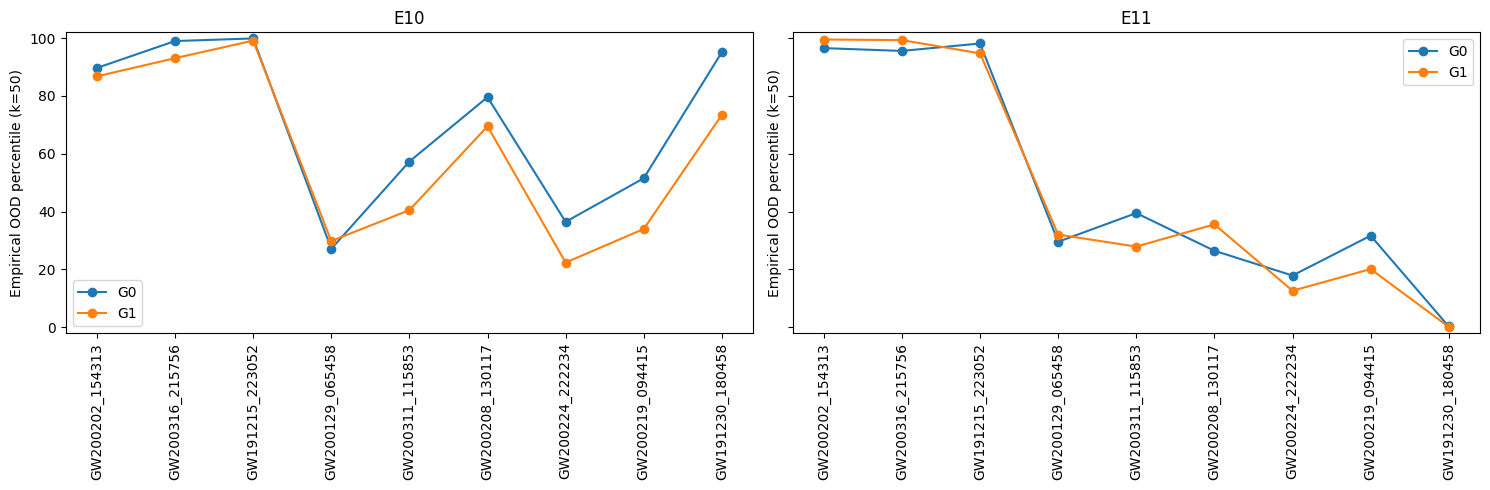

In [7]:
def neighbor_radii(query, reference, self_query=False):
    search = NearestNeighbors(n_neighbors=max(KS)+int(self_query),algorithm="brute",
                              metric="euclidean",n_jobs=1).fit(reference)
    out = np.empty((len(query),len(KS)),dtype=np.float64)
    for start in range(0,len(query),128):
        distances,indices = search.kneighbors(query[start:start+128])
        for offset,(dist,ids) in enumerate(zip(distances,indices)):
            if self_query:
                dist = dist[ids != start+offset]
            require(len(dist)>=max(KS), "Insufficient nonself neighbors")
            out[start+offset] = dist[np.array(KS)-1]
    require(np.isfinite(out).all(), "Nonfinite radii")
    return out

def empirical_percentile(value, reference):
    return float(100*np.searchsorted(np.sort(reference),value,side="right")/len(reference))

radii, geometry_rows, real_rows = {}, [], []
for encoder,arrays in scaled.items():
    radii[encoder] = {}
    for target in ("G0","G1"):
        for source in ("G0","G1","real"):
            radii[encoder][(source,target)] = neighbor_radii(arrays[source],arrays[target],source==target)
    for j,k in enumerate(KS):
        medians = {d:float(np.median(radii[encoder][(d,d)][:,j])) for d in ("G0","G1")}
        require(all(v>0 for v in medians.values()), "Zero internal scale; normalization undefined")
        geometry_rows.append(dict(encoder=encoder,k=k,n_G0=30000,n_G1=30000,
            median_internal_G0=medians["G0"],median_internal_G1=medians["G1"],
            median_G0_to_G1=float(np.median(radii[encoder][("G0","G1")][:,j])),
            median_G1_to_G0=float(np.median(radii[encoder][("G1","G0")][:,j]))))
        for i,event in enumerate(event_names):
            row = dict(event=event,encoder=encoder,k=k)
            for d in ("G0","G1"):
                value = float(radii[encoder][("real",d)][i,j])
                row[f"raw_distance_{d}"] = value
                row[f"normalized_distance_{d}"] = value/medians[d]
                row[f"ood_percentile_{d}"] = empirical_percentile(value,radii[encoder][(d,d)][:,j])
            require(row["normalized_distance_G0"]>0, "Zero real G0 distance; ratio undefined")
            row["ratio_G1_over_G0"] = row["normalized_distance_G1"]/row["normalized_distance_G0"]
            real_rows.append(row)
synthetic_geometry = pd.DataFrame(geometry_rows)
latent_distances = pd.DataFrame(real_rows)
synthetic_geometry.to_csv(RESULT_ROOT / "synthetic_domain_geometry.csv",index=False)
latent_distances.to_csv(RESULT_ROOT / "real_event_latent_distances.csv",index=False)
display(synthetic_geometry)
for encoder in ("E10","E11"):
    print(encoder, "primary k=50; robustness retained in combined table")
    display(latent_distances.query("encoder == @encoder and k == 50"))
display(latent_distances)
fig,axes = plt.subplots(1,2,figsize=(15,5),sharey=True)
for ax,encoder in zip(axes,("E10","E11")):
    table = latent_distances.query("encoder == @encoder and k == 50").set_index("event").loc[event_names]
    for domain in ("G0","G1"):
        ax.plot(event_names,table[f"ood_percentile_{domain}"],"o-",label=domain)
    ax.set(title=encoder,ylabel="Empirical OOD percentile (k=50)",ylim=(-2,102))
    ax.tick_params(axis="x",rotation=90)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "real_event_ood_comparison.png",dpi=160,bbox_inches="tight")
plt.show()


## 9. Fixed domain classifier — diagnostic only
Balanced 30k+30k; fixed stratified 80/20 split seed 123, unoptimized logistic regression. Report held-out ROC AUC and accuracy; AUC near 0.5 suggests absence of linear separability, not equality of distributions. High AUC indicates retained domain information, without assuming it is preferable. The common scaler includes all synthetic points as required in Section 4; it is not a prospective generalization benchmark. Convergence warnings are retained and flagged, never trigger tuning.

In [8]:
import warnings
from sklearn.exceptions import ConvergenceWarning
classifier_rows = []
for encoder,arrays in scaled.items():
    features = np.concatenate([arrays["G0"],arrays["G1"]])
    targets = np.repeat([0,1],30000)
    train_ids,test_ids = train_test_split(np.arange(60000),test_size=0.2,
                                         random_state=SEED,stratify=targets)
    classifier = LogisticRegression(C=1.0,solver="lbfgs",max_iter=1000,random_state=SEED)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always",ConvergenceWarning)
        classifier.fit(features[train_ids],targets[train_ids])
    for warning in caught:
        print(encoder,str(warning.message))
    classifier_rows.append(dict(encoder=encoder,seed=SEED,n_train=len(train_ids),n_test=len(test_ids),
        roc_auc=roc_auc_score(targets[test_ids],classifier.predict_proba(features[test_ids])[:,1]),
        accuracy=accuracy_score(targets[test_ids],classifier.predict(features[test_ids])),
        converged=not any(issubclass(w.category,ConvergenceWarning) for w in caught),
        scaler_scope="balanced 60k synthetic; no real",C=1.0,max_iter=1000))
classifier_metrics = pd.DataFrame(classifier_rows)
classifier_metrics.to_csv(RESULT_ROOT / "domain_classifier_metrics.csv",index=False)
display(classifier_metrics)


,encoder,seed,n_train,n_test,roc_auc,accuracy,converged,scaler_scope,C,max_iter
0,E10,123,48000,12000,0.858724,0.782333,True,balanced 60k synthetic; no real,1.0,1000
1,E11,123,48000,12000,0.710471,0.655500,True,balanced 60k synthetic; no real,1.0,1000


## 10. PCA — visualization only
Fit PCA to all 60k scaled synthetic embeddings, excluding R. Plot a fixed subsample of synthetic points only for readability. All quantitative distances remain in 64D using complete sets. PCA plots are illustrative and are **not** used to define domain distance.

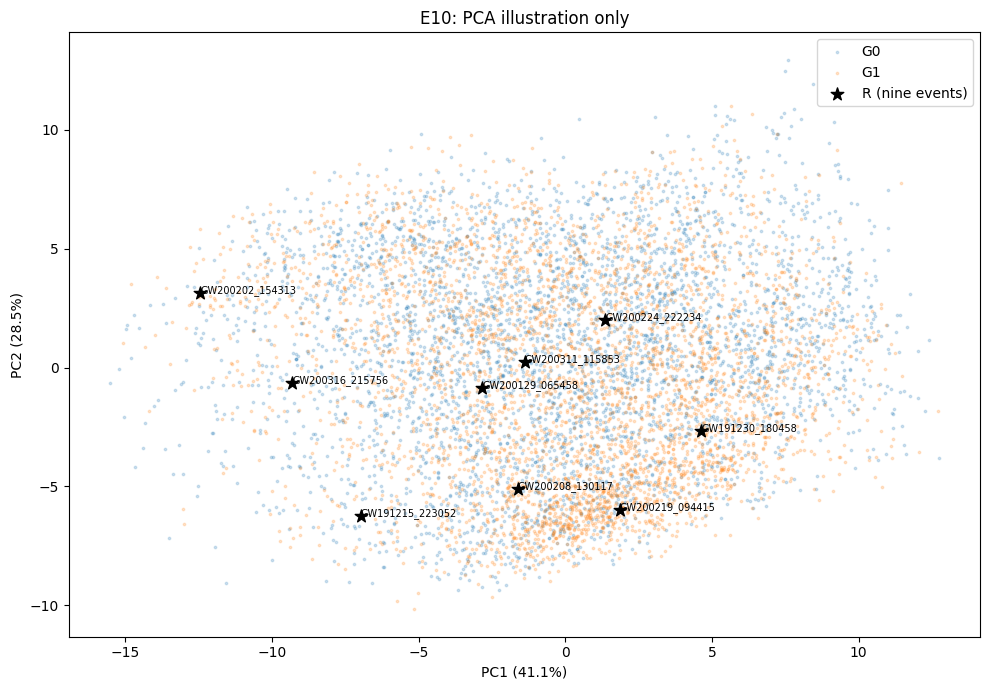

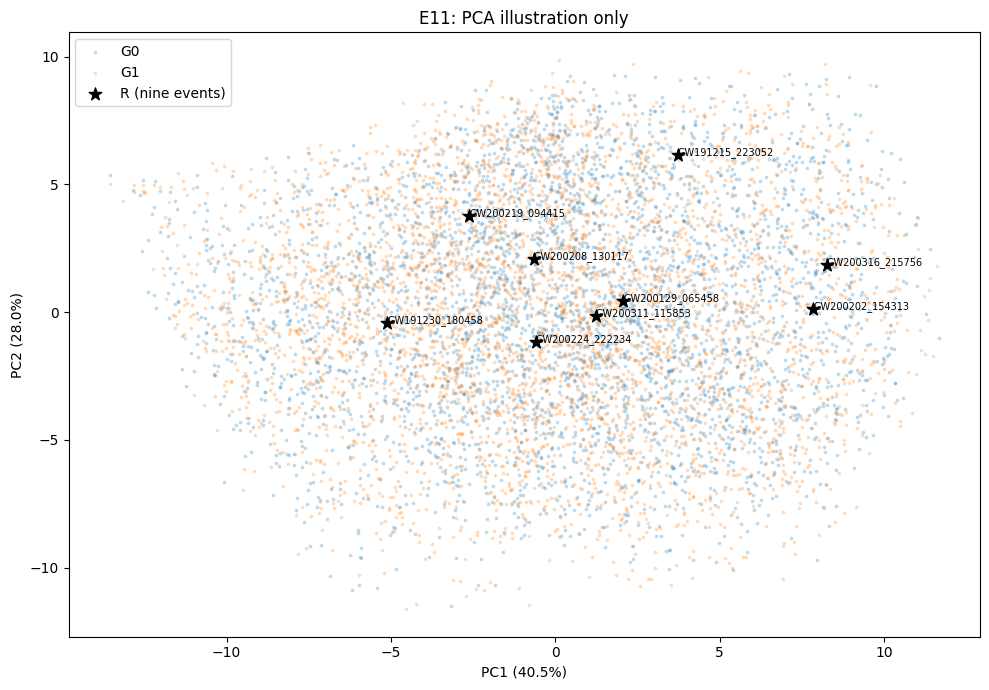

Explained variance: {'E10': [0.4109378755092621, 0.2851814329624176], 'E11': [0.40468236804008484, 0.2803378999233246]}


In [9]:
pca_variance = {}
for encoder,arrays in scaled.items():
    pca = PCA(n_components=2,svd_solver="full").fit(np.concatenate([arrays["G0"],arrays["G1"]]))
    pca_variance[encoder] = pca.explained_variance_ratio_.tolist()
    rng = np.random.default_rng(SEED)
    fig,ax = plt.subplots(figsize=(10,7))
    for domain in ("G0","G1"):
        points = pca.transform(arrays[domain])
        chosen = rng.choice(len(points),size=4000,replace=False)
        ax.scatter(*points[chosen].T,s=3,alpha=.2,label=domain,rasterized=True)
    points = pca.transform(arrays["real"])
    ax.scatter(*points.T,color="black",marker="*",s=90,label="R (nine events)")
    for event,point in zip(event_names,points):
        ax.annotate(event,point,fontsize=7)
    ax.set(title=f"{encoder}: PCA illustration only",
           xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{encoder}_pca_domains_real.png",dpi=160,bbox_inches="tight")
    plt.show()
print("Explained variance:",pca_variance)


## 11. Connect to M11.15A — nine-event descriptive comparison
Use frozen M11.14 detector-frame LVK central values and absolute discrepancies. Add M11.15A's Mahalanobis percentile if persisted; otherwise explicitly missing (no new label geometry fit). Positive Delta_error = abs_error_M10 − abs_error_M11 means improvement relative to LVK, which is an uncertain reference, not ground truth. Compare prediction improvement against E11's normalized G1/G0 ratio; lower ratio means relatively closer to G1. No inferential claims or hyperparameter selection from these nine points.

,event,network_snr_lvk,chirp_mass_lvk,M10_chirp_mass_discrepancy,M11_chirp_mass_discrepancy,Delta_error_chirp_mass,total_mass_lvk,M10_total_mass_discrepancy,M11_total_mass_discrepancy,Delta_error_total_mass,...,M10_chi_eff_discrepancy,M11_chi_eff_discrepancy,Delta_error_chi_eff,mahalanobis_percentile,E10_ood_percentile_G0,E10_ood_percentile_G1,E10_ratio_G1_over_G0,E11_ood_percentile_G0,E11_ood_percentile_G1,E11_ratio_G1_over_G0
0,GW200202_154313,10.8,8.1641,2.453911,6.999732,-4.545821,19.1622,8.691456,20.709270,-12.017815,...,0.393547,0.126536,0.267012,90.910000,89.686667,86.776667,0.927880,96.536667,99.520000,1.553358
1,GW200316_215756,10.3,10.6750,1.832020,3.234145,-1.402126,25.8640,6.215116,9.231554,-3.016438,...,0.058954,0.070907,-0.011953,85.300000,98.983333,93.060000,0.704403,95.570000,99.306667,1.512179
2,GW191215_223052,11.2,24.8400,8.310353,1.621442,6.688911,58.4550,18.257630,3.810551,14.447079,...,0.443656,0.337585,0.106071,38.546667,99.890000,99.143333,0.754384,98.143333,94.740000,0.889860
3,GW200129_065458,26.8,32.0960,1.966104,0.854669,1.111436,74.6940,3.248391,0.649025,2.599366,...,0.125243,0.087100,0.038143,19.986667,27.103333,29.823333,1.027685,29.563333,32.063333,0.980336
4,GW200311_115853,17.8,32.7180,1.709157,1.824385,-0.115228,76.1370,6.348121,5.560659,0.787462,...,0.102605,0.057892,0.044713,17.013333,57.313333,40.510000,0.861943,39.483333,27.890000,0.845887
5,GW200208_130117,10.8,38.7800,8.780338,1.987950,6.792388,91.4200,13.649156,2.932795,10.716360,...,0.307677,0.141535,0.166142,4.280000,79.580000,69.503333,0.881976,26.456667,35.590000,1.056482
6,GW200224_222234,20.0,41.0520,2.103595,0.620746,1.482848,95.4360,5.797085,0.506392,5.290693,...,0.072495,0.025975,0.046520,6.790000,36.456667,22.366667,0.886587,17.883333,12.633333,0.896481
7,GW200219_094415,10.7,43.3320,4.502106,2.411392,2.090714,102.0500,6.351077,3.873451,2.477626,...,0.498843,0.317714,0.181129,3.693333,51.540000,33.993333,0.863954,31.673333,20.120000,0.838887
8,GW191230_180458,10.4,61.6850,12.305186,9.961835,2.343351,145.3400,30.877622,20.912775,9.964847,...,0.340034,0.063014,0.277020,46.246667,95.150000,73.470000,0.668928,0.260000,0.136667,0.915142


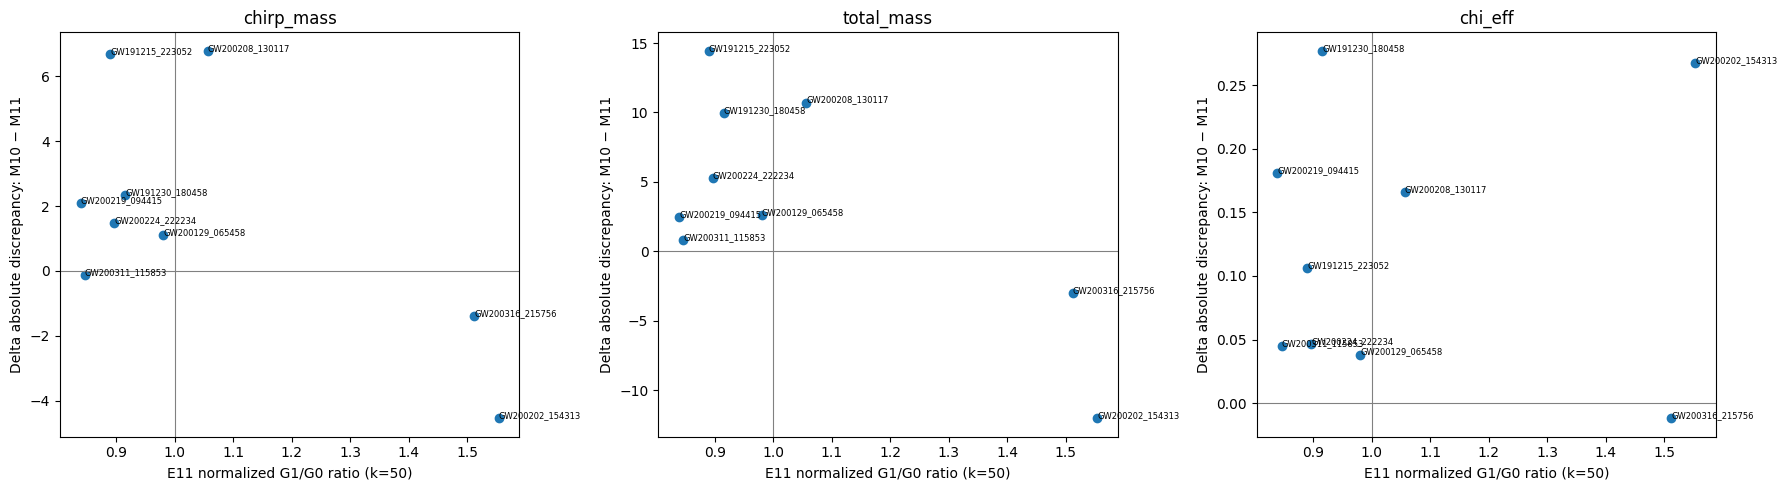

In [10]:
comparison = pd.read_csv(COMPARISON_PATH)
require(not comparison.duplicated(["event","label"]).any(), "Duplicate comparisons")
require(set(comparison.event) == set(event_names), "Comparison cohort changed")
joined = cohort[["event","network_snr_lvk"]].copy()
for label in LABELS:
    table = comparison.loc[comparison.label.eq(label)].set_index("event")
    require(set(table.index) == set(event_names), "Incomplete paired labels")
    joined[f"{label}_lvk"] = joined.event.map(table.lvk_central)
    for model in ("M10","M11"):
        joined[f"{model}_{label}_discrepancy"] = joined.event.map(table[f"absolute_discrepancy_{model}"])
    joined[f"Delta_error_{label}"] = joined[f"M10_{label}_discrepancy"]-joined[f"M11_{label}_discrepancy"]
require(np.isfinite(joined.drop(columns="event").to_numpy(float)).all(), "Nonfinite paired values")
joined["mahalanobis_percentile"] = np.nan
if M15A_PATH.is_file():
    m15a = pd.read_csv(M15A_PATH)
    require(not m15a.event.duplicated().any() and set(event_names)<=set(m15a.event), "M11.15A cohort")
    for label in LABELS:
        require(np.allclose(joined[f"{label}_lvk"],joined.event.map(m15a.set_index("event")[f"{label}_lvk"])),
                "M11.15A reference mismatch")
    if "mahalanobis_percentile" in m15a:
        joined["mahalanobis_percentile"] = joined.event.map(m15a.set_index("event").mahalanobis_percentile)
for encoder in ("E10","E11"):
    table = latent_distances.query("encoder == @encoder and k == 50").set_index("event")
    for column in ("ood_percentile_G0","ood_percentile_G1","ratio_G1_over_G0"):
        joined[f"{encoder}_{column}"] = joined.event.map(table[column])
joined.to_csv(RESULT_ROOT / "real_event_latent_vs_prediction.csv",index=False)
display(joined)
fig,axes = plt.subplots(1,3,figsize=(18,5))
for ax,label in zip(axes,LABELS):
    x,y = joined.E11_ratio_G1_over_G0,joined[f"Delta_error_{label}"]
    ax.scatter(x,y)
    for event,a,b in zip(joined.event,x,y):
        ax.annotate(event,(a,b),fontsize=6)
    ax.axhline(0,color="grey",lw=.8)
    ax.axvline(1,color="grey",lw=.8)
    ax.set(title=label,xlabel="E11 normalized G1/G0 ratio (k=50)",
           ylabel="Delta absolute discrepancy: M10 − M11")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "latent_ratio_vs_prediction_improvement.png",dpi=160,bbox_inches="tight")
plt.show()


## 12. Outputs and reproducibility
Caches, four result CSVs and provenance are written under `DATA_ROOT/results/M11_final_G1_500k/M11_15B_latent_domain_geometry/`; four requested PNG figures are under `figures/`. No large pairwise matrices are saved. Scaler parameters and PCA explained variances are recorded; exact ordered test IDs are in the cross cache. Full computations are deferred to explicit execution.

In [11]:
provenance = dict(contract=contract,real_contract=real_contract,
    comparison=fingerprint(COMPARISON_PATH,True),
    m15a=fingerprint(M15A_PATH,True) if M15A_PATH.is_file() else None,
    caches={p.name:fingerprint(p,True) for p in (CROSS_CACHE,REAL_CACHE)},
    notebook=fingerprint(PROJECT_ROOT / "notebooks/m11/M11_15B_latent_domain_geometry.ipynb",True),
    metric=dict(type="balanced synthetic StandardScaler per encoder; Euclidean 64D",
                k=list(KS),primary_k=50,neighbor="kth; exact brute; query batches128",
                self_exclusion="index-based",percentile="100 * fraction <= real distance"),
    scalers={e:dict(mean=s.mean_.tolist(),scale=s.scale_.tolist()) for e,s in metric_scalers.items()},
    pca_explained_variance=pca_variance,seed=SEED,
    real_event_metadata=metadata,gw170814="outside frozen M11.14 cohort; existing anchor untouched",
    versions={name:getattr(sys.modules.get(name),"__version__",None)
              for name in ("numpy","pandas","sklearn","h5py","torch")})
(RESULT_ROOT / "provenance.json").write_text(json.dumps(provenance,indent=2),encoding="utf-8")
print("Outputs:",RESULT_ROOT)


Outputs: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/M11_15B_latent_domain_geometry


## 13. Interpretation and conclusions

### 13.1 Synthetic-domain geometry

The latent-space analysis shows that the original synthetic domain G0 and the
final G1 domain remain distinguishable under both encoders, but their separation
is substantially reduced under the M11 encoder.

For the primary $k=50$ metric, under E10 the median internal distances are
$$
d_{\rm int}^{G0}=1.475,\qquad
d_{\rm int}^{G1}=1.775,
$$

while the cross-domain distances are
$$
d(G0\rightarrow G1)=1.768,\qquad
d(G1\rightarrow G0)=1.996.
$$

Thus, cross-domain neighbourhood distances are approximately 20% and 12%
larger than the corresponding within-domain scales.

Under E11 the same quantities become
$$
d_{\rm int}^{G0}=1.566,\qquad
d_{\rm int}^{G1}=1.382,
$$

and
$$
d(G0\rightarrow G1)=1.639,\qquad
d(G1\rightarrow G0)=1.467,
$$

corresponding to only approximately 5--6% excess cross-domain distance.
The same conclusion is stable for $k=20$ and $k=100$.

The fixed linear domain classifier provides independent evidence for the same
effect. Its held-out ROC AUC decreases from
$$
{\rm AUC}_{E10}=0.859
$$

to
$$
{\rm AUC}_{E11}=0.710,
$$

with accuracy decreasing from 0.782 to 0.656. Therefore, G0/G1 domain identity
is substantially less linearly separable in the E11 representation.

This suggests that E11 has learned a more domain-invariant latent
representation rather than simply reproducing the geometry learned by E10.

### 13.2 Relative compatibility of real events with G0 and G1

For each real event we define
$$
R =
\frac{\tilde d_k({\rm real},G1)}
     {\tilde d_k({\rm real},G0)},
$$

where each distance is normalized by the median internal $k$-NN scale of the
corresponding synthetic domain.

Under E10, the real events show a strong preference for G1:

- 9/9 events have $R<1$ for $k=20$;
- 8/9 for $k=50$;
- 8/9 for $k=100$.

For the primary $k=50$ analysis the median ratio is approximately
$$
{\rm median}(R_{E10})\simeq0.864.
$$

Thus the G0 $\rightarrow$ G1 modifications moved the synthetic domain in a
direction that is globally more compatible with real data even when evaluated
using the original E10 encoder.

Under E11 the distinction becomes weaker. For $k=50$, 6/9 events have
$R<1$, with
$$
{\rm median}(R_{E11})\simeq0.915.
$$

This should not be interpreted as a failure of G1. Because E11 makes G0 and G1
considerably less separable, the G1/G0 ratio itself becomes a less discriminating
quantity.

### 13.3 Real-event OOD behaviour

A stronger effect is visible in the event-wise OOD percentiles.

For several intermediate- and high-mass events, the E11 representation places
the real signal much deeper inside the synthetic latent support. Examples for
the G1-relative OOD percentile include
$$
{\rm GW191230}: 73.5\%\rightarrow0.14\%,
$$
$$
{\rm GW200224}: 22.4\%\rightarrow12.6\%,
$$
$$
{\rm GW200219}: 34.0\%\rightarrow20.1\%,
$$
$$
{\rm GW200311}: 40.5\%\rightarrow27.9\%,
$$

and
$$
{\rm GW200208}: 69.5\%\rightarrow35.6\%.
$$

This indicates that E11 maps a substantial fraction of the real-event cohort
into regions that are much more typical of the synthetic representation.

The main exceptions are the two low-mass events GW200202_154313 and
GW200316_215756. Under E11 they become extreme outliers relative to G1:
$$
P_{\rm OOD}^{G1}\simeq99.5\%,\qquad99.3\%,
$$

respectively, and their normalized G1/G0 ratios are
$$
R\simeq1.55,\qquad1.51.
$$

Thus these events are not only peripheral in physical parameter space, as found
in M11.15A, but are also poorly represented by the E11/G1 latent manifold.

### 13.4 Relation to physical prediction improvements

The latent-space behaviour is qualitatively consistent with the real-event
prediction results.

The two low-mass latent outliers are also the two clearest M11 failures in the
mass parameters:
$$
\Delta_{\mathcal M}({\rm GW200202})=-4.55,\qquad
\Delta_{M_{\rm tot}}({\rm GW200202})=-12.02,
$$

and
$$
\Delta_{\mathcal M}({\rm GW200316})=-1.40,\qquad
\Delta_{M_{\rm tot}}({\rm GW200316})=-3.02,
$$

where positive $\Delta$ denotes improvement from M10 to M11.

Conversely, several events that become better integrated into the E11 latent
support show large improvements in mass estimation, including GW191215,
GW200208, GW200224 and GW191230.

However, latent OOD status is not a sufficient predictor of parameter error.
GW191215 remains highly OOD while showing a large prediction improvement.
Likewise, $\chi_{\rm eff}$ improves for 8/9 events even when the global latent
distance remains large.

Therefore the 64-dimensional Euclidean geometry should be interpreted as a
global domain diagnostic, not as a direct surrogate for parameter-specific
regression error.

### 13.5 Combined interpretation with M11.15A

Taken together, M11.15A and M11.15B support the following interpretation.

M11 does not appear to improve real-data transfer simply because G1 is an exact
match to the real domain. Instead, training on the more realistic G1 domain
changes the learned representation itself.

Compared with E10, E11:

1. reduces the separability between G0 and G1;
2. maps many real events into regions substantially more typical of the shared
   synthetic latent support;
3. improves real-event stability and parameter estimates for most of the
   tested cohort;
4. still fails for a specific low-mass, low-SNR, peripheral regime.

This is consistent with E11 learning a more domain-invariant representation at
the cost of some synthetic-domain specialization. Such a trade-off can explain
why M11 performs slightly worse than M10 on the synthetic test set while
transferring substantially better to real data.

The remaining low-mass failure mode is compatible with the combination already
identified in M11.15A:
$$
\text{parameter-space peripherality}
+
\text{low information/SNR}
+
\text{regression toward the training centre}
+
\text{poor latent-domain compatibility}.
$$

No single factor alone explains the behaviour.

### 13.6 PCA and robustness checks

The first two PCA components explain approximately 69.6% of the synthetic
latent variance for E10 and 68.5% for E11. The projections visually support the
stronger G0/G1 mixing under E11, but PCA is used only as an illustration and
not as quantitative evidence.

The principal kNN conclusions are stable across $k=20,50,100$, reducing the
likelihood that they are an artefact of a particular neighbourhood scale.

### 13.7 Limitations

Several limitations remain important:

- only nine real H1-L1-V1 events are included;
- E10 and E11 define different latent coordinate systems, so raw distances
  must never be compared directly across encoders;
- the OOD percentiles and normalized ratios are descriptive diagnostics, not
  calibrated probabilities;
- the LVK central values are reference estimates rather than ground truth;
- G0 and G1 differ in several generation and preprocessing choices, so this
  experiment cannot identify which individual change caused the latent-domain
  improvement;
- a global Euclidean latent distance can obscure parameter-specific directions;
- real-event proximity to G1 is neither necessary nor sufficient for improved
  regression performance.

### 13.8 Final conclusion

The strongest result of M11.15B is not that real data are universally closer
to G1 than to G0. Rather, the M11 encoder substantially compresses the
G0/G1 domain distinction and places many real events deeper inside a common
synthetic latent manifold.

This provides a plausible representation-level explanation for the improved
real-data transfer observed in M11 despite its slightly worse synthetic test
metrics.

The main unresolved regime is the low-mass, low-SNR edge of parameter space,
where both regression-to-the-mean and latent-domain mismatch remain severe.